In [1]:
%load_ext autoreload
%autoreload 2
# !hostname
# !pwd
import os, sys
# print(sys.executable)
# os.environ['CUDA_VISIBLE_DEVICES'] = "7"
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = "false"
# sys.path.append(os.path.abspath(".."))

In [2]:
import os, sys, glob, pickle, copy, time
from functools import partial

import numpy as np
import pandas as pd
# import xarray as xr
import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = (15, 5)
import seaborn as sns
sns.set_theme()

from tqdm.auto import tqdm
from einops import rearrange, reduce, repeat
# from einop import einop

import jax
import jax.numpy as jnp
from jax.random import split

# import flax
# import flax.linen as nn
# from flax.training.train_state import TrainState

# import optax

import experiment_utils
import util
# from main import *
import plotstyle
plotstyle.set_plot_style()

In [3]:
import torch
from x_transformers import AutoregressiveWrapper, TransformerWrapper, Decoder

In [ ]:
# model = AutoregressiveWrapper(TransformerWrapper(num_tokens = 20000, max_seq_len = 1024, attn_layers = Decoder(dim = 512, depth = 1, heads = 8, rotary_pos_emb=False))).cuda()
# x = torch.randint(0, 20000, (1, 1024)).cuda()
# model(x) # (1, 1024, 20000)
# prompt = torch.randint(0, 20000, (8, 16)).cuda()
# model.generate(prompt, seq_len=1024-16, temperature=1.).shape

tensor(10.0521, device='cuda:0', grad_fn=<NllLoss2DBackward0>)

In [5]:
import train_gpt_pt
argd = train_gpt_pt.Args()

argd.n_iters = 30000
argd.log_every = 3000

argd.opt.batch_size = 128
argd.opt.grad_accum_steps = 4

argd.model.n_layer = 6
argd.model.d_model = 512
argd.model.n_heads = 8
argd.model.vocab_size = 512
argd.model.ctx_len = 1600
argd.model.rotary_pos_emb = False

argd.data.gol_params = 6152
argd.data.t_start = 32
argd.data.t_end = 64
argd.data.grid_size = 30
argd.data.timesteps = 16
argd.data.dt = 1
argd.data.patch_size = 3

args_all = []
seeds_all = range(1)
gol_params_all = [6152, 7291, 7787, 55871]
dts_all = [1, 2, 4, 8, 16]
for seed in seeds_all:
    for gol_params in gol_params_all:
        for dt in dts_all:
            args = copy.deepcopy(argd)
            args.seed = seed
            args.data.gol_params = gol_params
            args.data.dt = dt
            args.model.ctx_len = 1600//dt

            if dt == 1:
                args.opt.grad_accum_steps = 4
            else:
                args.opt.grad_accum_steps = 2

            args.save_dir = f"/home/akarsh_sakana_ai/alife-repr-data/train_gpt_pt_0/seed={seed}_gol_params={gol_params}_dt={dt}"
            args_all.append(args)
experiment_utils.create_commands(args_all, prefix="python train_gpt_pt.py", out_file="science_scripts/train_gpt_pt.sh");

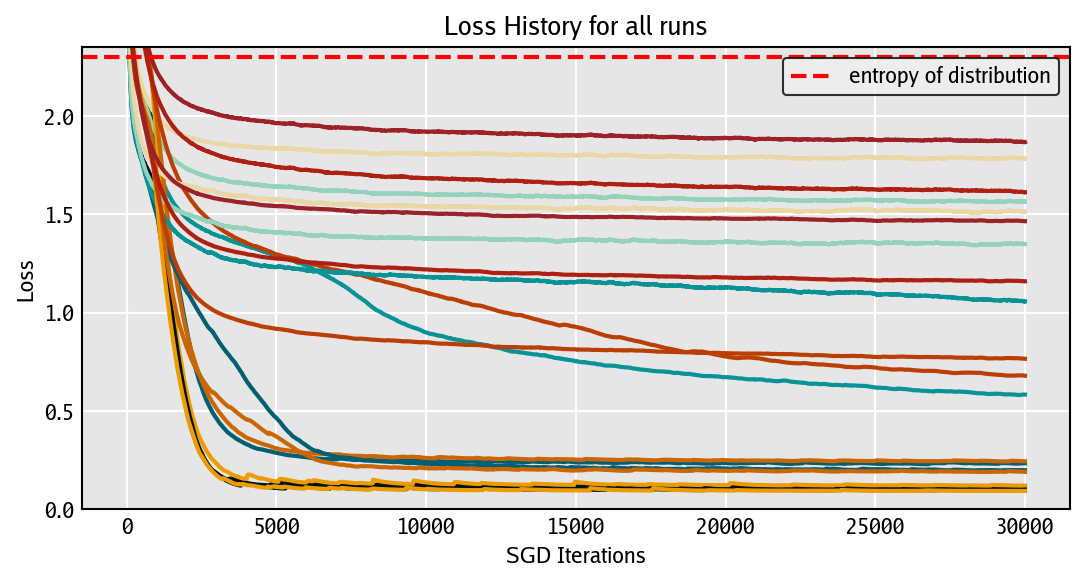

In [7]:
for args in args_all:
    loss_history = util.load_pkl(args.save_dir, "loss_history")
    # plt.plot(loss_history)
    plt.plot(pd.DataFrame(loss_history).ewm(span=1000).mean())
plt.axhline(y=2.3, color='red', linestyle='--', label='entropy of distribution')
plt.legend()
plt.ylim(0, 2.35)
plt.xlabel("SGD Iterations")
plt.ylabel("Loss")
plt.title("Loss History for all runs")
plt.show()

In [8]:
df = []

for args in args_all:
    loss_final = util.load_pkl(args.save_dir, "final_loss")
    iter_per_sec = util.load_pkl(args.save_dir, "iter_per_sec")
    dfi = dict(seed=args.seed, gol_params=str(args.data.gol_params), dt=args.data.dt, loss_final=loss_final, iter_per_sec=iter_per_sec)
    df.append(dfi)
df = pd.DataFrame(df)

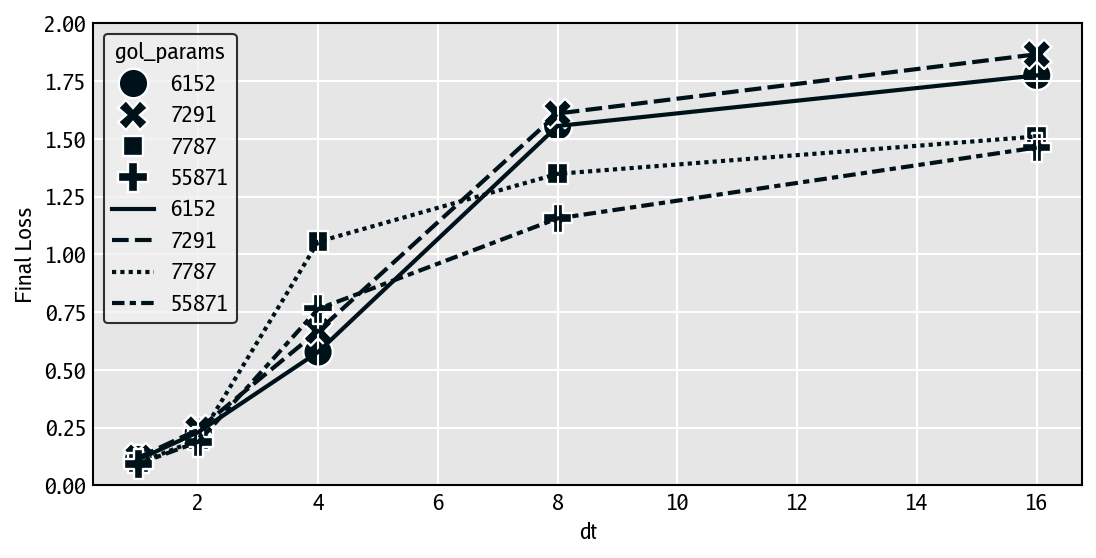

In [10]:
sns.scatterplot(data=df, x='dt', y='loss_final', style='gol_params', s=200)
sns.lineplot(data=df, x='dt', y='loss_final', style='gol_params')
# plt.xscale('log')
# plt.xticks(dts_all, dts_all);

plt.ylim(0, 2.)

plt.xlabel("dt")
plt.ylabel("Final Loss")
plt.show()


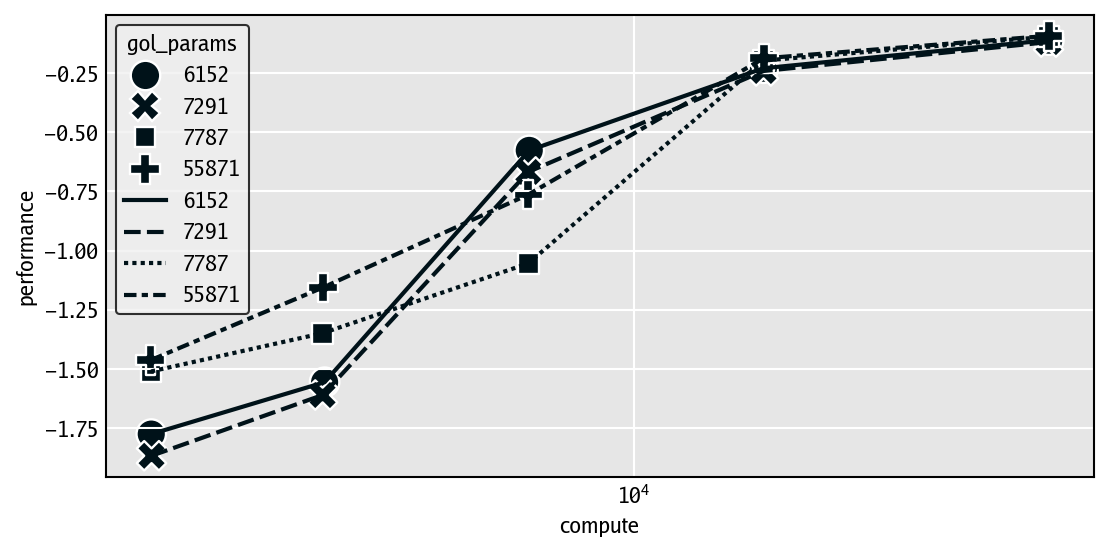

In [11]:
df['compute'] = 1./df['iter_per_sec'] * 30000
df['performance'] = -df['loss_final']

sns.scatterplot(data=df, x='compute', y='performance', style='gol_params', s=200)
sns.lineplot(data=df, x='compute', y='performance', style='gol_params')
plt.xscale('log')
# plt.yscale('log')

In [12]:
args = copy.deepcopy(args_all[4])
args.opt.batch_size = 16
main = train_gpt_pt.Main(args)
main.init()

main.model = torch.load(f"{args.save_dir}/model.pt", weights_only=False)
print(main.do_iter_eval(None)['loss'])

Number of parameters: 19,471,872
1.6598138213157654


In [13]:
batch = main.data_gen.generate_batch(None)['data']
batch.shape

torch.Size([16, 100])

In [14]:
n_tokens_per_frame = (args.data.grid_size//args.data.patch_size)**2
prompt = batch[:, :n_tokens_per_frame]
generation = main.model.generate(prompt, seq_len=args.model.ctx_len-n_tokens_per_frame, temperature=0.1, )
generation = torch.cat([prompt, generation], dim=1)

In [15]:
generation.shape

torch.Size([16, 100])

In [18]:
from substrates.gol_pt import int2binary
def tokens_to_state(args, tokens):
    shape = tokens.shape
    patches = int2binary(tokens[..., None], n_bits=9).reshape(*shape, -1)
    state = rearrange(patches, "B (T H W) (h w) -> B T (H h) (W w)",
                      H=args.data.grid_size//args.data.patch_size, W=args.data.grid_size//args.data.patch_size,
                      h=args.data.patch_size, w=args.data.patch_size)
    return state

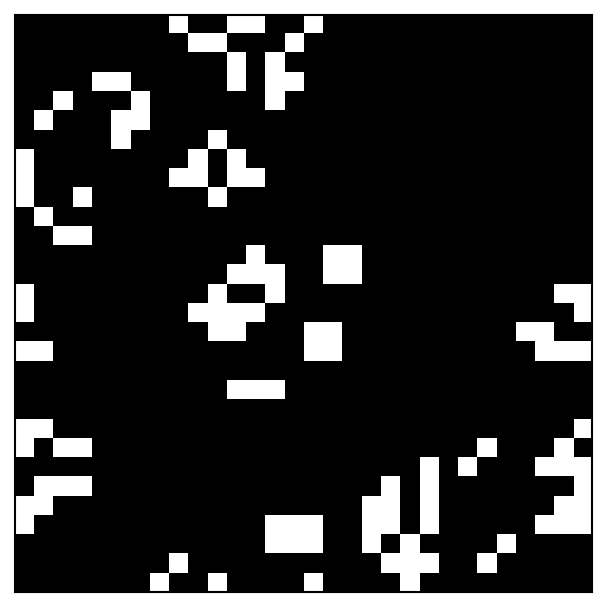

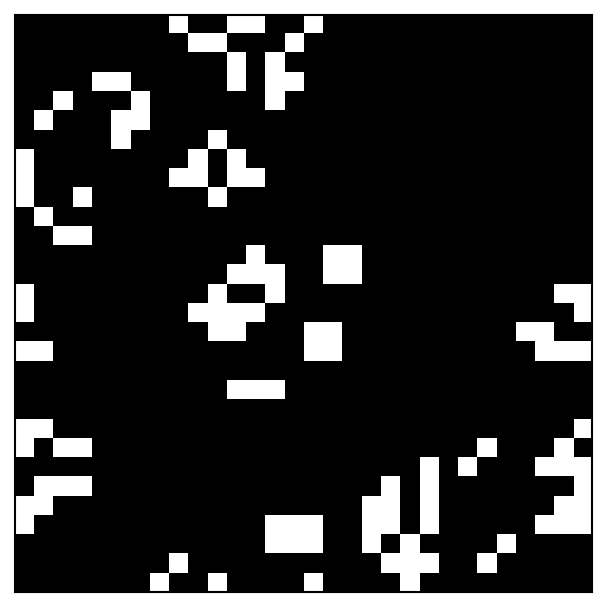

In [117]:
state = tokens_to_state(args, batch).detach().cpu().numpy()
i = 3

plt.figure(figsize=(20, 5))
plt.imshow(rearrange(state[i], "T H W -> H (T W)"), cmap="gray", vmin=0, vmax=1)
plt.xticks([]); plt.yticks([])
plt.show()

state = tokens_to_state(args, generation).detach().cpu().numpy()

plt.figure(figsize=(20, 5))
plt.imshow(rearrange(state[i], "T H W -> H (T W)"), cmap="gray", vmin=0, vmax=1)
plt.xticks([]); plt.yticks([])
plt.show()

In [47]:
def compute_generation_accuracy(args, batch_size=64, n_rollouts=5):
    args = copy.deepcopy(args)
    args.opt.batch_size = batch_size
    main = train_gpt_pt.Main(args)
    n_tokens_per_frame = (args.data.grid_size//args.data.patch_size)**2

    main.model = torch.load(f"{args.save_dir}/model.pt", weights_only=False)

    batches, generations = [], []
    for _ in range(n_rollouts):
        batch = main.data_gen.generate_batch(None)['data']
        prompt = batch[:, :n_tokens_per_frame]
        generation = main.model.generate(prompt, seq_len=args.model.ctx_len-n_tokens_per_frame, temperature=1.0, )
        generation = torch.cat([prompt, generation], dim=1)
        batches.append(batch)
        generations.append(generation)

    batches = torch.cat(batches, dim=0)
    generations = torch.cat(generations, dim=0)

    state = tokens_to_state(args, batches).detach().cpu().numpy()[:, 1:]
    state_gen = tokens_to_state(args, generations).detach().cpu().numpy()[:, 1:]
    state_gen_naive = (state.mean(axis=(-1, -2))+.5).astype(int)[:, :, None, None]
    accuracy = (state==state_gen).mean()
    accuracy_naive = (state==state_gen_naive).mean()
    state, state_gen = tokens_to_state(args, batches).detach().cpu().numpy(), tokens_to_state(args, generations).detach().cpu().numpy()
    return accuracy.item(), accuracy_naive.item(), state, state_gen

In [ ]:
df = []
for args in tqdm(args_all):
    loss_final = util.load_pkl(args.save_dir, "final_loss")
    iter_per_sec = util.load_pkl(args.save_dir, "iter_per_sec")
    accuracy, accuracy_naive, _, _ = compute_generation_accuracy(args)
    dfi = dict(seed=args.seed, gol_params=str(args.data.gol_params), dt=args.data.dt, loss_final=loss_final, iter_per_sec=iter_per_sec, accuracy=accuracy, accuracy_naive=accuracy_naive)
    df.append(dfi)
df = pd.DataFrame(df)

  0%|          | 0/20 [00:00<?, ?it/s]

/var/tmp/ipykernel_991644/2847719188.py:24: RuntimeWarning: Mean of empty slice.
  accuracy = (state==state_gen).mean()
/home/akarsh_sakana_ai/.conda/envs/alife-repr-torch/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/tmp/ipykernel_991644/2847719188.py:25: RuntimeWarning: Mean of empty slice.
  accuracy_naive = (state==state_gen_naive).mean()


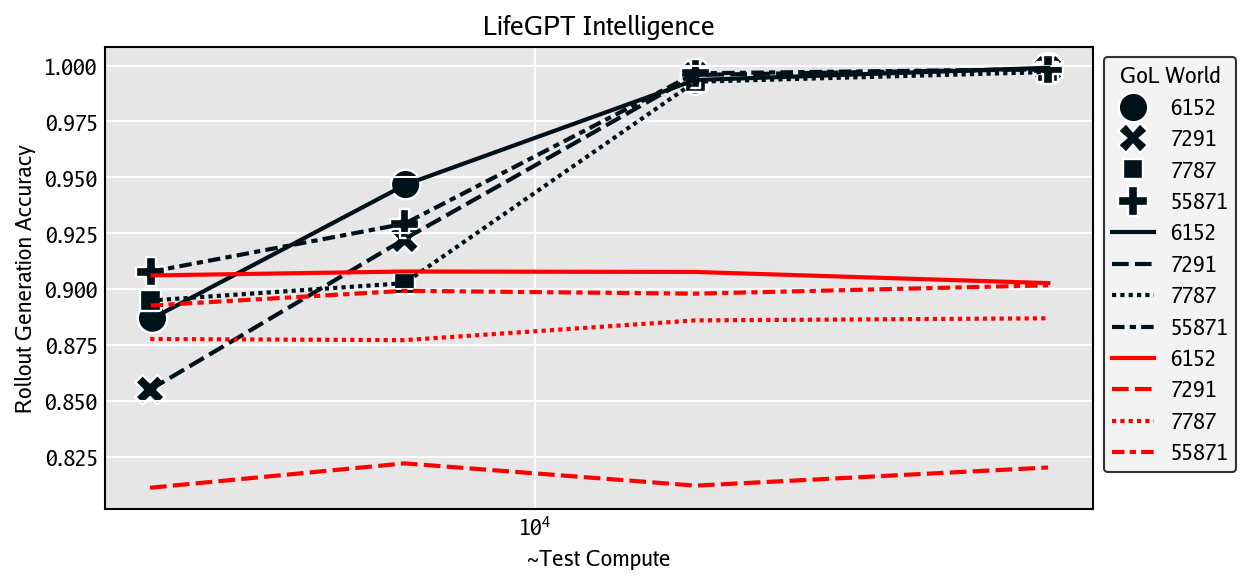

In [37]:
df['compute'] = 1./df['iter_per_sec'] * 30000
# df['performance'] = -df['loss_final']
sns.scatterplot(data=df, x='compute', y='accuracy', style='gol_params', s=200)
sns.lineplot(data=df, x='compute', y='accuracy', style='gol_params')
sns.lineplot(data=df, x='compute', y='accuracy_naive', style='gol_params', c='red')
plt.xscale('log')
plt.legend(title='GoL World', bbox_to_anchor=(1., 1))
plt.xlabel("~Test Compute")
plt.ylabel("Rollout Generation Accuracy")
plt.title("LifeGPT Intelligence")
plt.show()

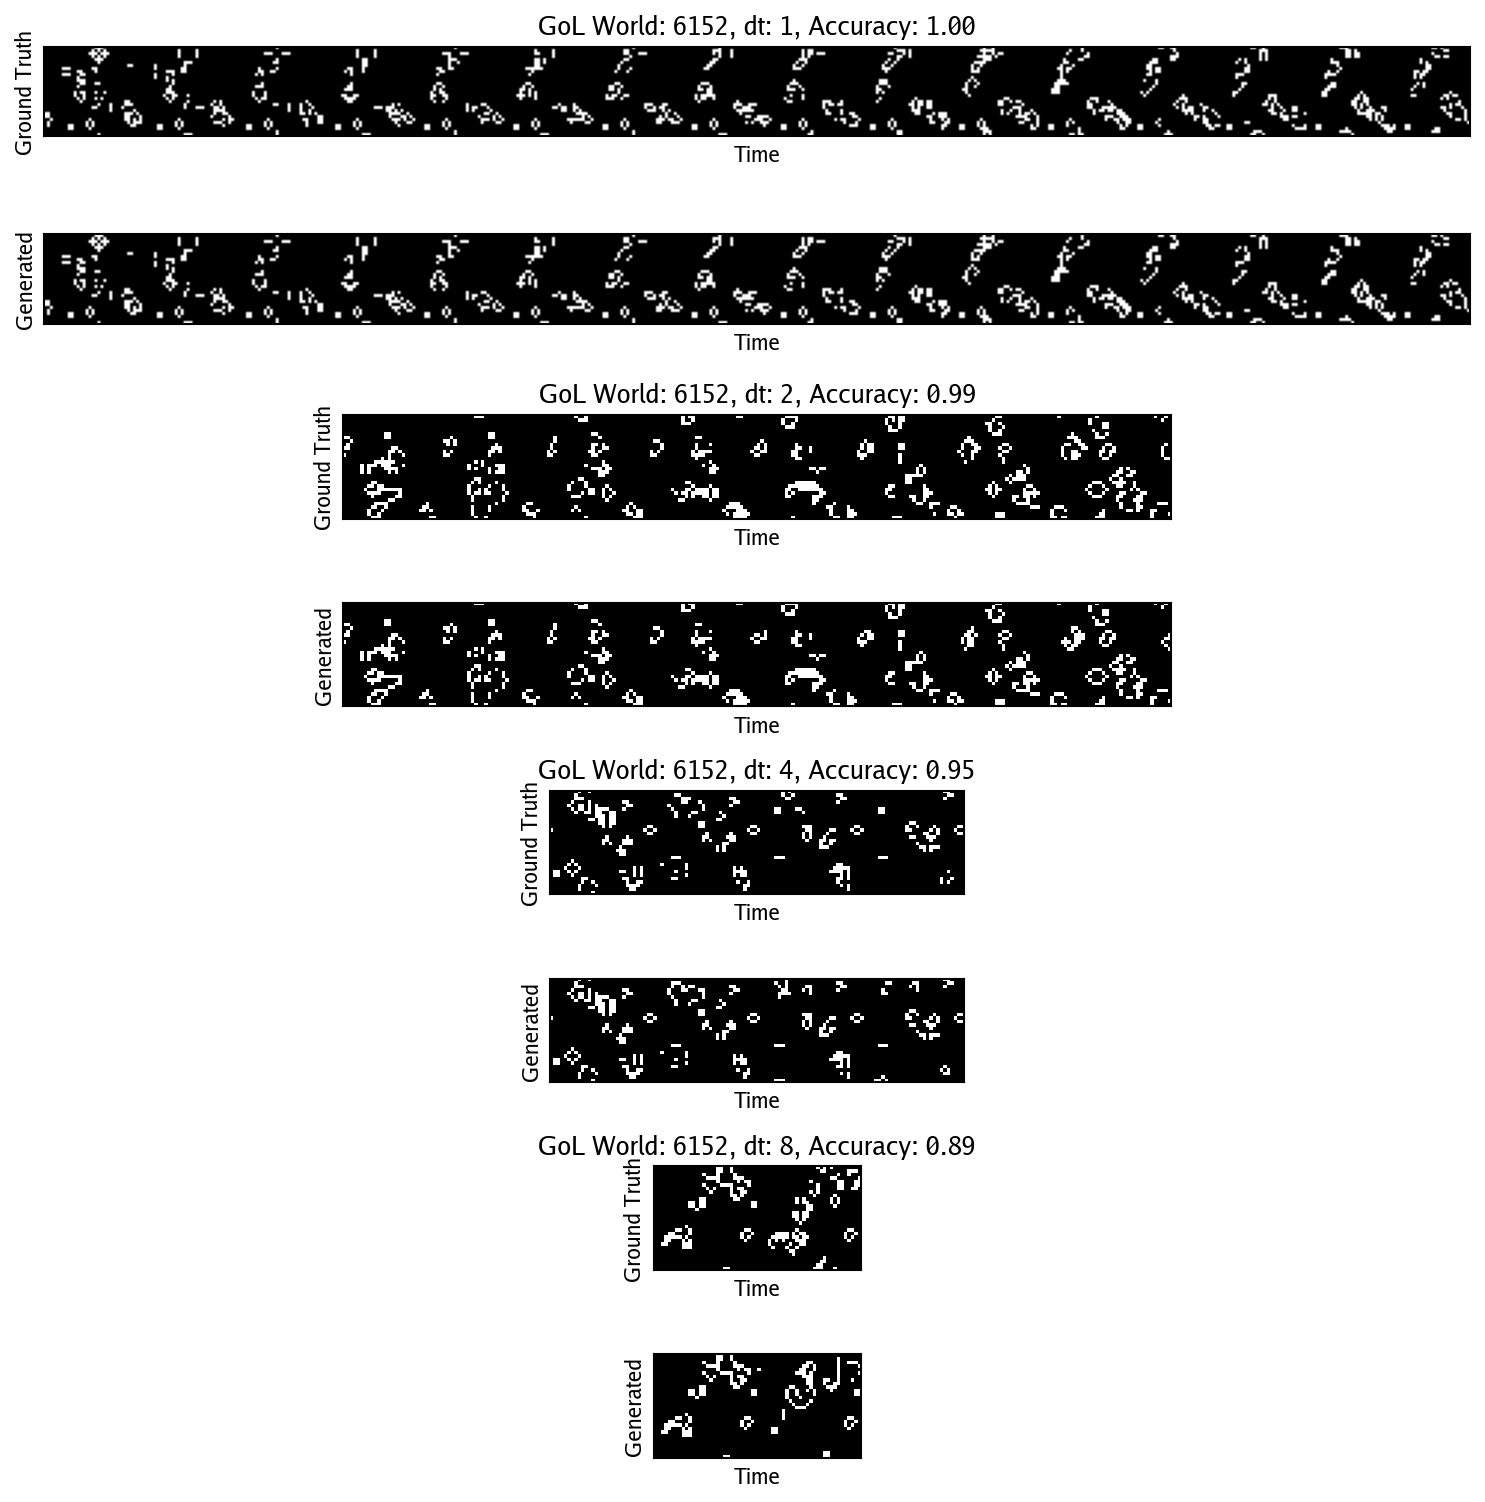

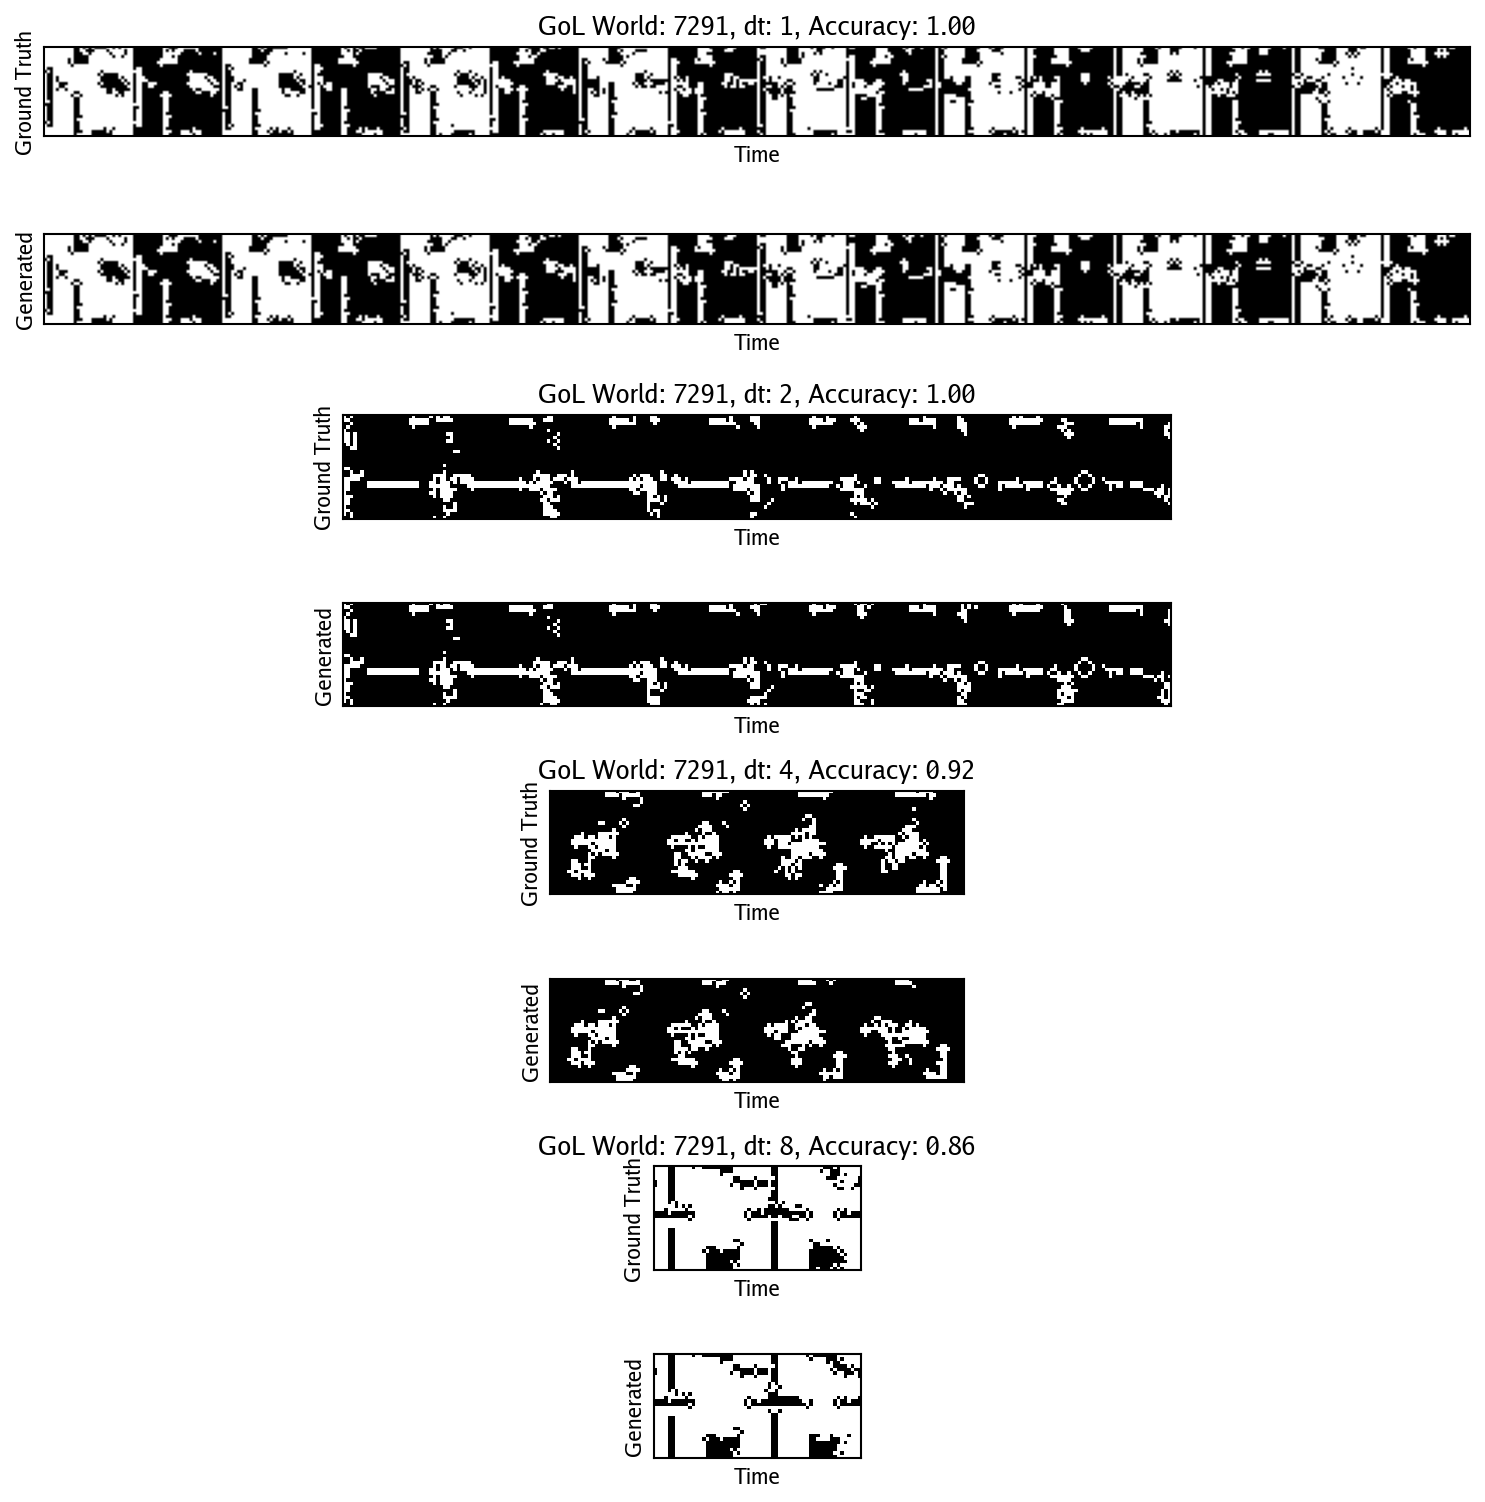

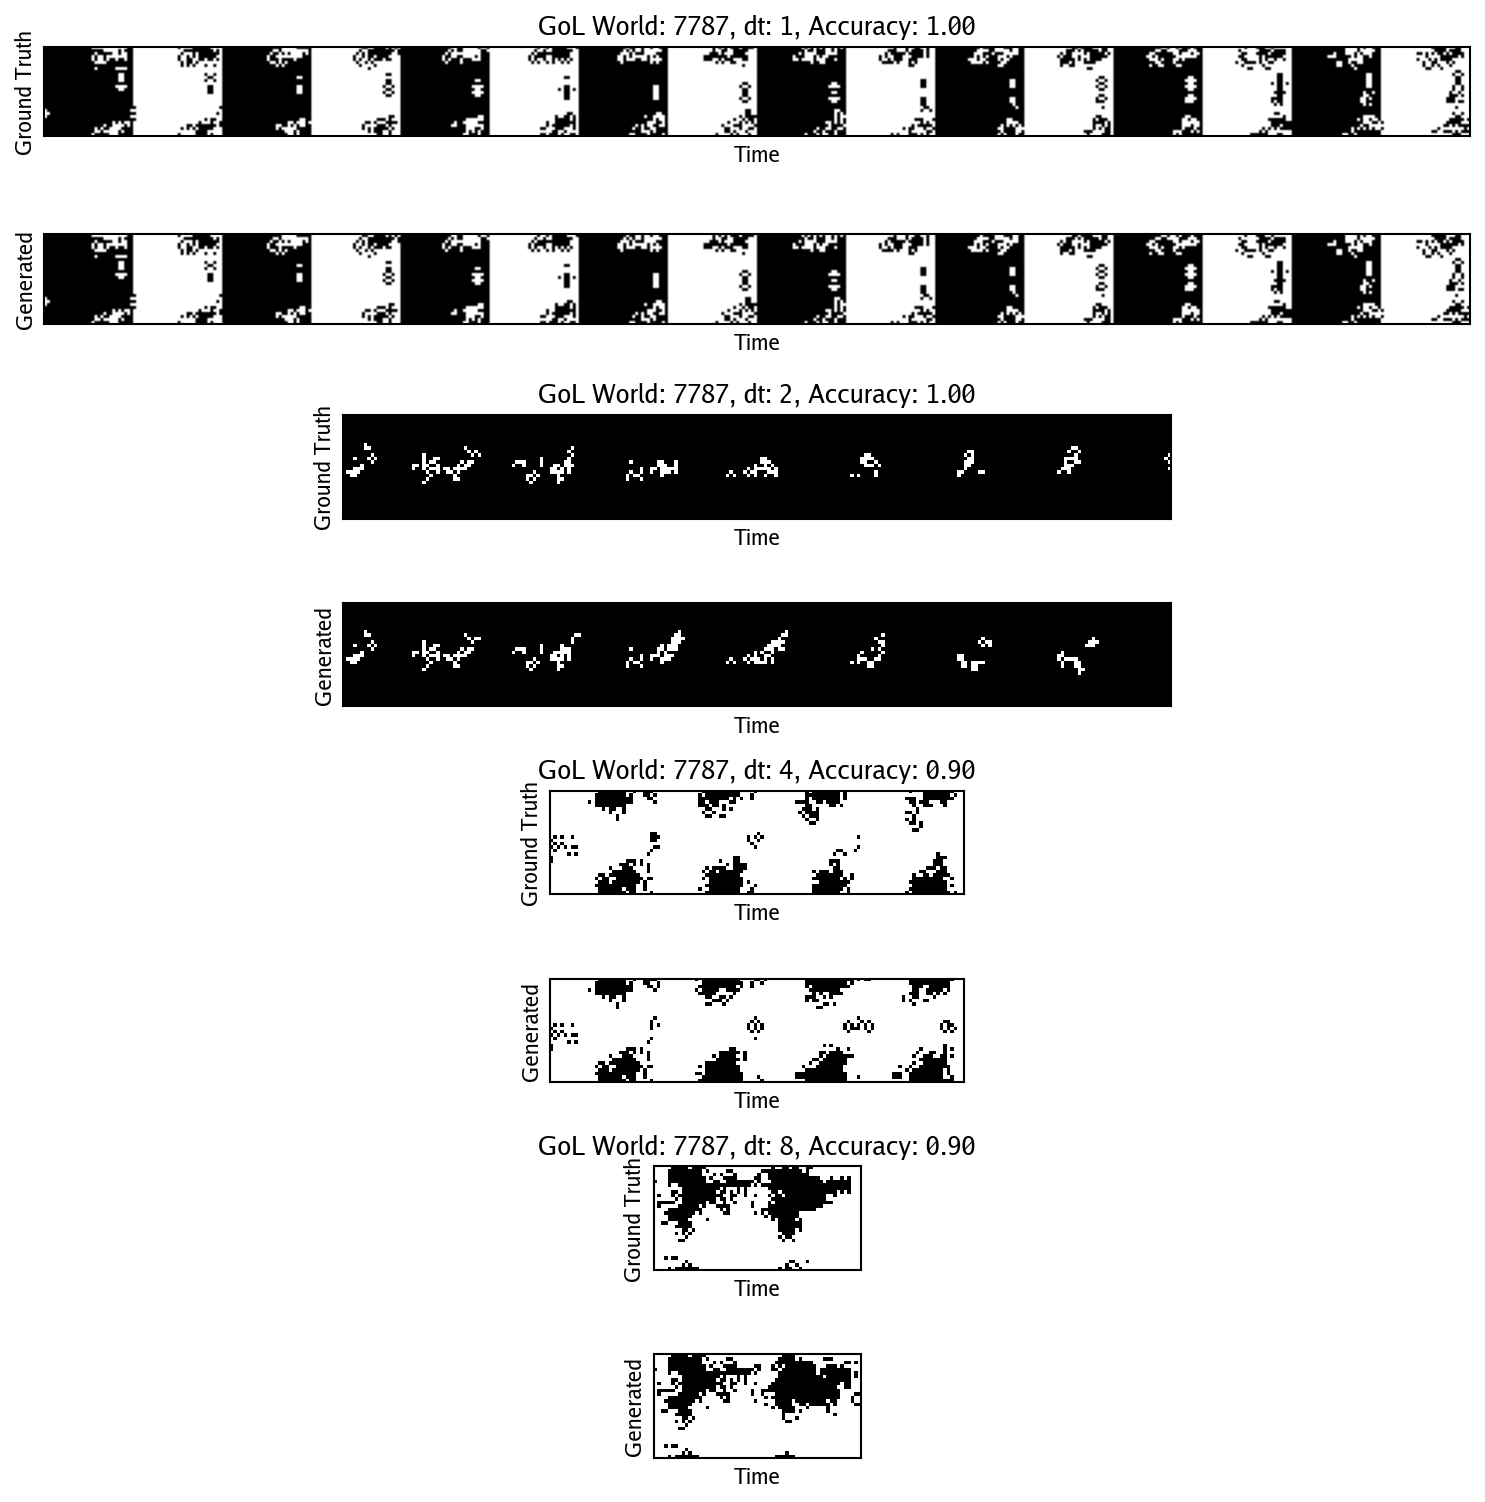

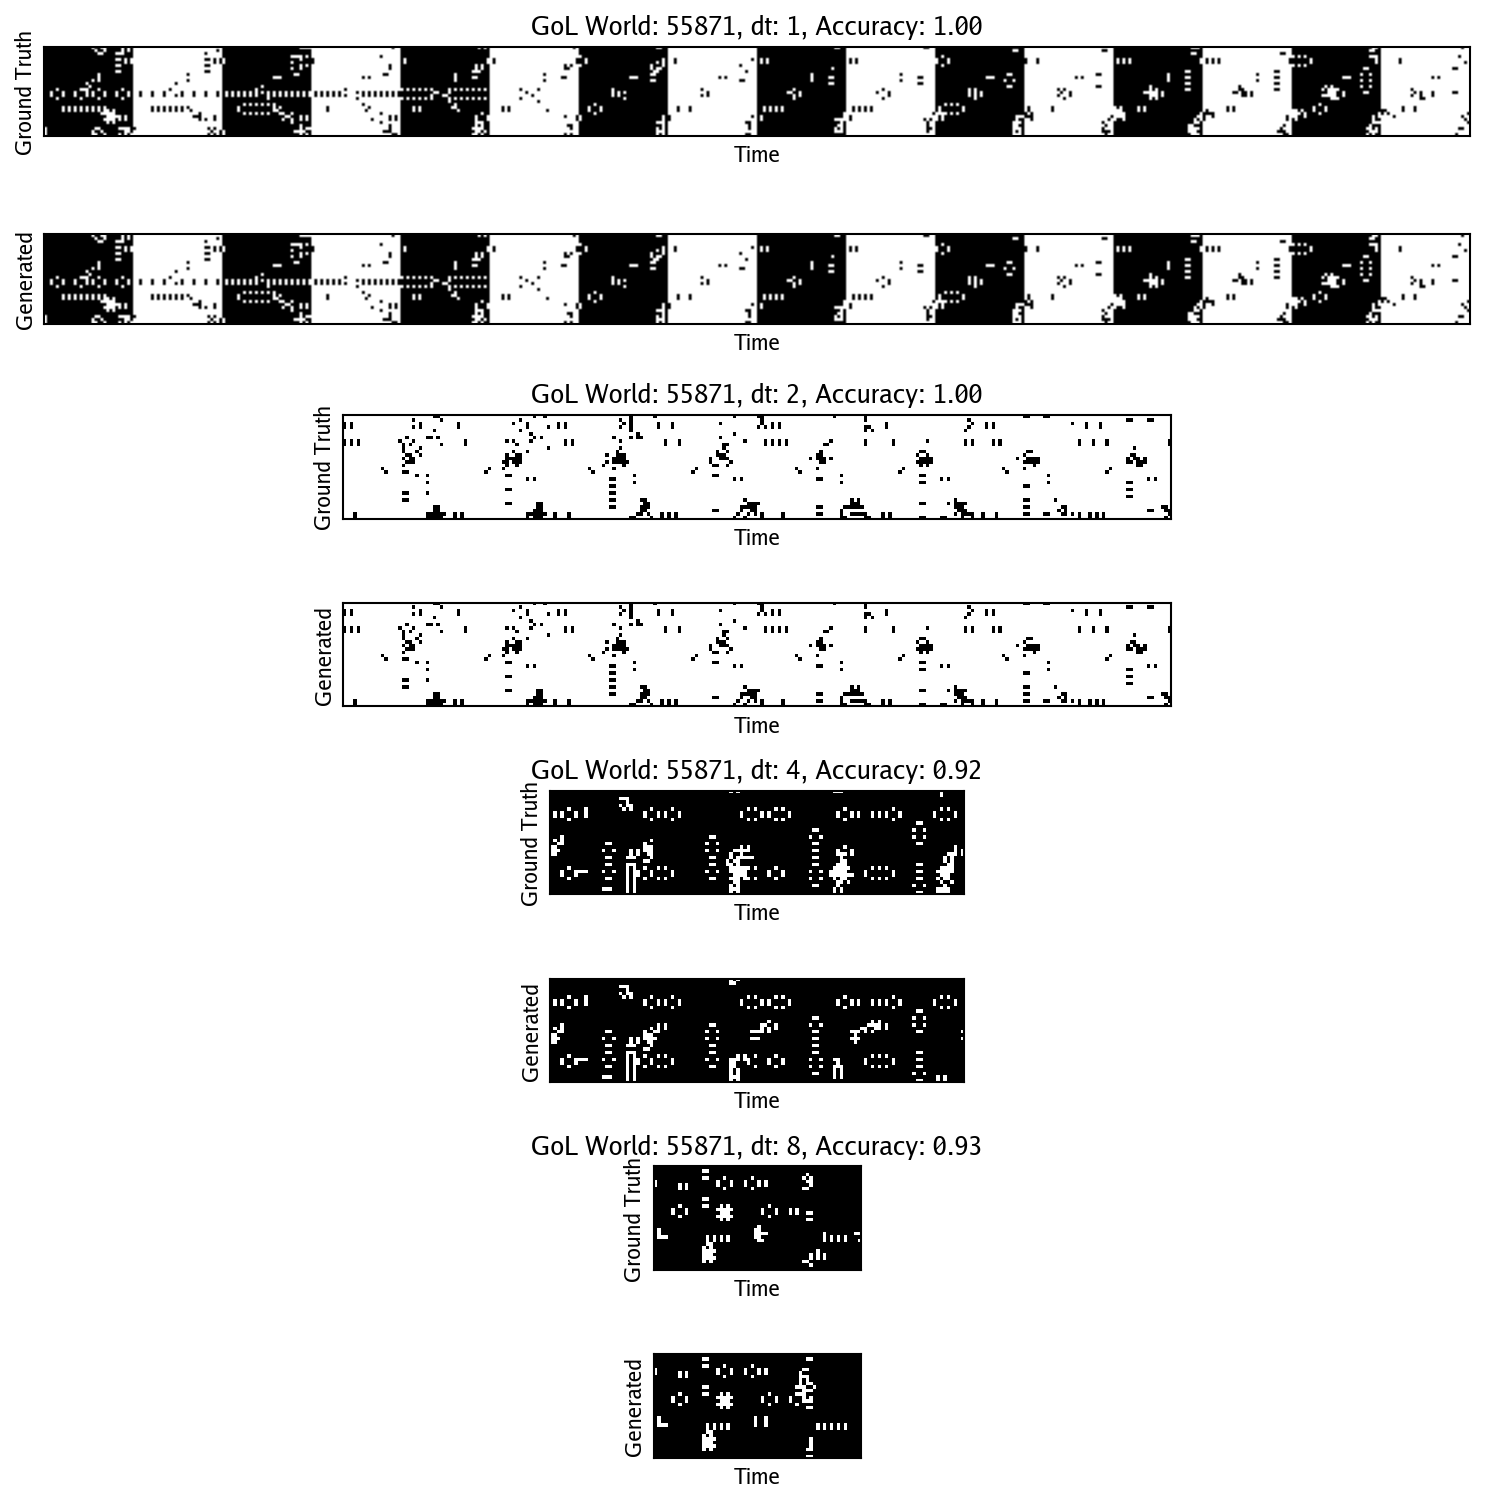

In [62]:
for args_list in [args_all[0:4], args_all[5:9], args_all[10:14], args_all[15:19]]:
    i = 0
    iplt = 0
    plt.figure(figsize=(10, 10), dpi=150)
    for args in args_list:
        args = copy.deepcopy(args)
        accuracy, accuracy_naive, state, state_gen = compute_generation_accuracy(args, batch_size=16, n_rollouts=1)
        i = np.argsort(state[:, ::2].var(axis=1).mean(axis=(-1, -2)))[8].item()

        iplt += 1
        plt.subplot(8, 1, iplt)
        plt.imshow(rearrange(state[i], "T H W -> H (T W)"), cmap="gray", vmin=0, vmax=1)
        plt.xticks([]); plt.yticks([]); plt.ylabel("Ground Truth"); plt.xlabel("Time")
        plt.title(f"GoL World: {args.data.gol_params}, dt: {args.data.dt}, Accuracy: {accuracy:.2f}")
        iplt += 1
        plt.subplot(8, 1, iplt)
        plt.imshow(rearrange(state_gen[i], "T H W -> H (T W)"), cmap="gray", vmin=0, vmax=1)
        plt.xticks([]); plt.yticks([]); plt.ylabel("Generated"); plt.xlabel("Time")
    plt.tight_layout()
    plt.show()

In [205]:
a, b = main.model.net(batch, return_intermediates=True)

In [208]:
torch.stack(b.hiddens, axis=1).shape

torch.Size([16, 6, 200, 512])

In [115]:
import train_gpt_pt
from train_gpt_pt import *
save_dir = "/home/akarsh_sakana_ai/alife-repr-data/temp/run3"
args = util.load_pkl(save_dir, "args")
loss_history = util.load_pkl(save_dir, "loss_history")
grad_norm_history = util.load_pkl(save_dir, "grad_norm_history")

[autoreload of train_gpt_pt failed: Traceback (most recent call last):
  File "/home/akarsh_sakana_ai/.conda/envs/alife-repr-torch/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/home/akarsh_sakana_ai/.conda/envs/alife-repr-torch/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/home/akarsh_sakana_ai/.conda/envs/alife-repr-torch/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/home/akarsh_sakana_ai/.conda/envs/alife-repr-torch/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 349, in update_class
    if update_generic(old_obj, new_obj):
  File "/home/akarsh_sakana_ai/.conda/envs/alife-repr-torch/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/home/akarsh_sakan

In [43]:
main = Main(args)

In [61]:
counts = 0
for i in tqdm(range(100)):
    rng = jax.random.PRNGKey(i)
    batch = main.data_gen.generate_batch(rng)['data']
    counts = counts + np.bincount(np.array(batch).flatten())

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:15<00:00,  6.58it/s]


In [74]:
probs = counts/counts.sum()

In [91]:
entropy = - (np.log(probs)*probs).sum()

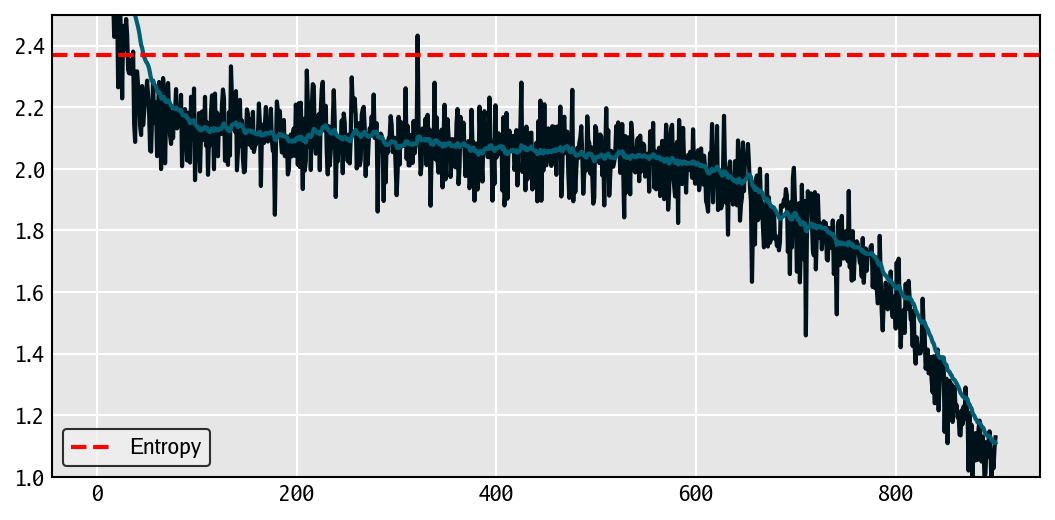

(0.0, 2.0)

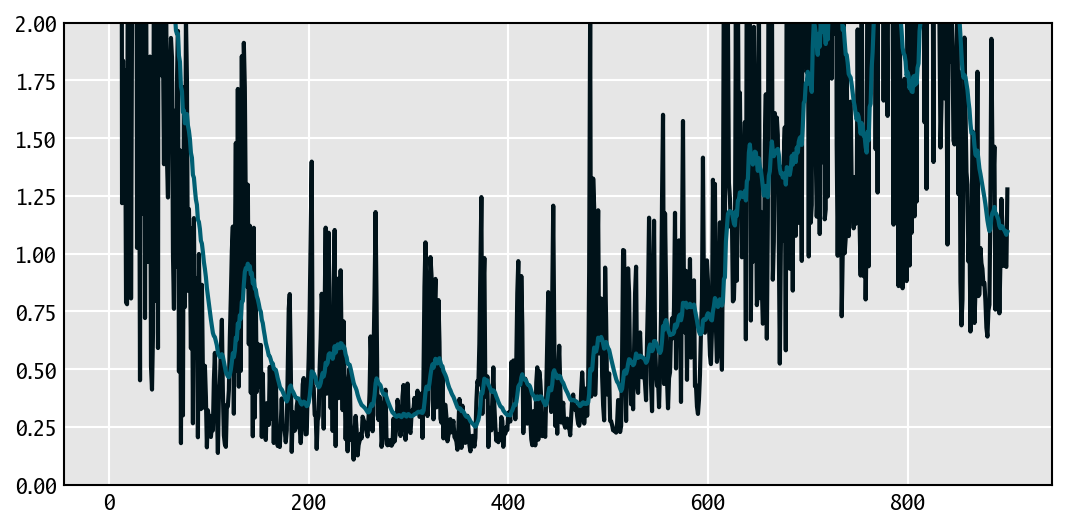

In [117]:
plt.plot(loss_history)
plt.plot(pd.DataFrame(loss_history).ewm(span=30).mean())
plt.axhline(entropy, color='red', linestyle='--', label='Entropy')
plt.legend()
plt.ylim(1.0, 2.5)
plt.show()

plt.plot(grad_norm_history)
plt.plot(pd.DataFrame(grad_norm_history).ewm(span=30).mean())
plt.ylim(0, 2.)

In [4]:
from train_gpt_pt import *

In [5]:
main = Main(Args())

In [29]:
%%time
main.data_gen.generate_batch(None)['data'].float().mean().item()

CPU times: user 10.1 ms, sys: 0 ns, total: 10.1 ms
Wall time: 9.87 ms


52.44853210449219